In [ ]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import quantnado
from quantnado.analysis.core import QuantNadoDataset

In [2]:
OUT_DIR = Path("profiling_output")
SAMPLES_DIR = OUT_DIR / "samples"
GTF_FILE = "local/gencode.v49.annotation.gtf"

### Profiling stats

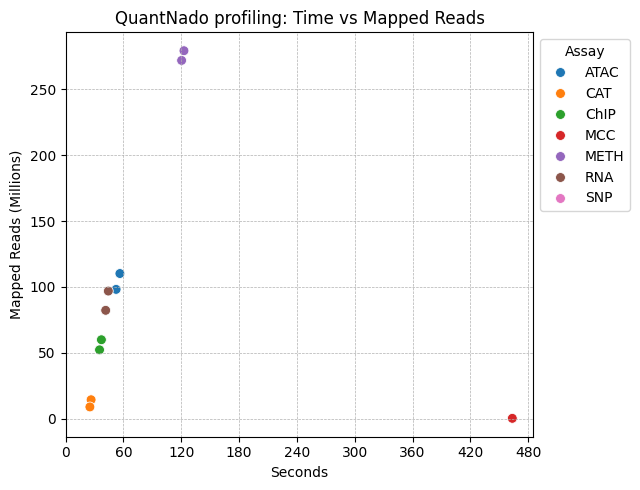

In [11]:
log_files = sorted(OUT_DIR.glob("profile_store_*.log"))

profile_df = []
for log_file in log_files:
    record = {"profile": log_file.stem.replace("profile_store_", "")}
    with open(log_file) as f:
        for line in f:
            if m := re.search(r"in (\d+\.\d+) seconds", line):
                record["seconds"] = float(m.group(1))
            if m := re.search(r"([\d,]+) mapped reads", line):
                record["mapped_reads"] = float(m.group(1).replace(",", ""))
            if m := re.search(r"([\d,]+) variants", line):
                record["variants"] = float(m.group(1).replace(",", ""))
            if m := re.search(r"Peak memory: (\d+\.\d+) GB", line):
                record["peak_memory"] = float(m.group(1))
    # if len(record) == 4:  # all fields found
        profile_df.append(record)

profile_df = pd.DataFrame(profile_df)
profile_df["assay"] = profile_df["profile"].apply(lambda x: x.split("-")[0]).replace({"CM": "ChIP", "TAPS": "METH", "gDNA": "SNP"})
profile_df["mapped_reads"] /= 1e6
profile_df.sort_values("assay", inplace=True)

plt.figure(figsize=(6.5, 5))
sns.scatterplot(data=profile_df, x="seconds", y="mapped_reads", hue="assay", s=50)
plt.xlabel("Seconds")
plt.ylabel("Mapped Reads (Millions)")
plt.title("QuantNado profiling: Time vs Mapped Reads")
plt.xticks(range(0, int(max(profile_df["seconds"]) + 60), 60))
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend(title="Assay", loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

### Make datasets

In [12]:
md_path = Path(OUT_DIR) / "quantnado_metadata.csv"

if md_path.exists():
    print(f"Metadata file exists: {md_path}")
    metadata = pd.read_csv(md_path)
else:
    metadata = (
        quantnado.metadata_from_seqnado("/Users/catherine/work/datasets", output_dir=OUT_DIR)
        .sort_values("sample_id")
        .groupby("assay")
        .head(2)
        .reset_index(drop=True)
    )

    mcc_row = pd.DataFrame(
        [
            {
                "assay": "MCC",
                "sample_id": "MCC-OCI-AML3",
                "bam_path": "tests/data/OCI-AML3-control-1-1-A_subsample.bam",
            }
        ]
    ).reindex(columns=metadata.columns)

    metadata = pd.concat([metadata, mcc_row], ignore_index=True)
    metadata.to_csv(md_path, index=False)

metadata

Metadata file exists: profiling_output/quantnado_metadata.csv


,assay,sample_id,ip,bam_path,stranded,methylation_path,variant_path
0,ATAC,ATAC-SEM-1,NaN,/Users/catherine/work/datasets/seqnado_output/...,NaN,NaN,NaN
1,ATAC,ATAC-SEM-2,NaN,/Users/catherine/work/datasets/seqnado_output/...,NaN,NaN,NaN
2,CUT&TAG,CAT-HSC_H3K27ac,H3K27ac,/Users/catherine/work/datasets/seqnado_output/...,NaN,NaN,NaN
3,CUT&TAG,CAT-HSC_MLLN,MLLN,/Users/catherine/work/datasets/seqnado_output/...,NaN,NaN,NaN
4,ChIP,CM-RCHACV-1_MLLN,MLLN,/Users/catherine/work/datasets/seqnado_output/...,NaN,NaN,NaN
5,ChIP,CM-RCHACV-1_Menin,Menin,/Users/catherine/work/datasets/seqnado_output/...,NaN,NaN,NaN
6,RNA,RNA-RCHACV-1,NaN,/Users/catherine/work/datasets/seqnado_output/...,R,NaN,NaN
7,RNA,RNA-RCHACV-2,NaN,/Users/catherine/work/datasets/seqnado_output/...,R,NaN,NaN
8,METH,TAPS-RCHACV,NaN,/Users/catherine/work/datasets/seqnado_output/...,NaN,/Users/catherine/work/datasets/seqnado_output/...,NaN
9,METH,TAPS-RS411,NaN,/Users/catherine/work/datasets/seqnado_output/...,NaN,/Users/catherine/work/datasets/seqnado_output/...,NaN


In [13]:
for _, row in metadata.iterrows():
    sample = row["sample_id"]
    assay = row["assay"]
    store = Path(SAMPLES_DIR / f"{sample}.zarr")

    if not store.exists():
        print(f"Processing {sample} ({assay})...")
        quantnado.create_dataset(
            sample_id=sample,
            assay=assay,
            output_path=store,
            bam_path=row.get("bam_path"),
            methyl_path=row.get("methylation_path"),
            variants_path=row.get("variant_path"),
            stranded=row.get("stranded", False),
            test=True, 
        )
    else:
        print(f"Store exists: {sample} ({assay})")

Store exists: ATAC-SEM-1 (ATAC)
Store exists: ATAC-SEM-2 (ATAC)
Store exists: CAT-HSC_H3K27ac (CUT&TAG)
Store exists: CAT-HSC_MLLN (CUT&TAG)
Store exists: CM-RCHACV-1_MLLN (ChIP)
Store exists: CM-RCHACV-1_Menin (ChIP)
Store exists: RNA-RCHACV-1 (RNA)
Store exists: RNA-RCHACV-2 (RNA)
Store exists: TAPS-RCHACV (METH)
Store exists: TAPS-RS411 (METH)
Store exists: gDNA-RCHACV (SNP)
Store exists: gDNA-SEM (SNP)
Store exists: MCC-OCI-AML3 (MCC)


### Combine

In [14]:
output_path = OUT_DIR / "dataset.zarr"
if not output_path.exists():
    QuantNadoDataset.combine(src=SAMPLES_DIR, output=output_path)

### Open zarr

In [15]:
qn = QuantNadoDataset(output_path, annotation=GTF_FILE)

ValueError: Cannot determine store layout for profiling_output/dataset.zarr

### Properties

In [ ]:
print("Sample names:\n", qn.sample_names)  # list[str]
print("Assays:\n", qn.assays)  # list[str]  — array keys present across stores
print("Chromosomes:\n", qn.chromosomes)  # list[str]  — excludes 'metadata' group
print("Chromsizes:\n", qn.chromsizes)  # dict[str, int]

### Region slice 

→ xr.Dataset  (1-based coords)

In [ ]:
region = qn.sel(chrom="chr21", start=34_785_801, end=35_051_302)
print(region)

### Standard xarray slicing

In [ ]:
region.sel(sample="ATAC-SEM-1")

In [ ]:
coverage = region.sel(sample=region.assay != "MCC")

In [ ]:
coverage = coverage.sel(position=slice(35_048_000, 35_050_000))

In [ ]:
coverage["coverage"].plot()  # x-axis = genomic coords

### Full genome 

→ xr.DataTree  (one node per chromosome)

In [ ]:
tree = qn.to_datatree(chromosomes=["chr21"], lazy=True)
tree

In [ ]:
tree["chr21"].ds.sel(position=slice(1_000_000, 2_000_000))

---
## Analysis

### Library sizes

Total mapped reads per sample, read from `metadata/total_reads` in each zarr store.

In [ ]:
from quantnado.analysis.normalise import get_library_sizes

lib_sizes = get_library_sizes(qn)
lib_sizes

### Normalisation

CPM-normalise a coverage DataArray. Works on any `xr.DataArray`, `xr.Dataset`, or `pd.DataFrame`.

In [ ]:
from quantnado.analysis.normalise import normalise

region = qn.sel(chrom="chr21", start=34_785_801, end=35_051_302)

# Normalise ATAC to CPM — library sizes are read automatically from the store
cpm = normalise(region["coverage"], qn,  method="cpm")
cpm

In [ ]:
cpm.plot()

In [ ]:
# Plot both samples in the region
cpm.plot.line(x="position", hue="sample", figsize=(14, 3))

### Annotation

In [ ]:
qn.set_annotation(GTF_FILE)

info = qn.gene_info("GNAQ")
print(info)

In [ ]:
region = qn.sel_gene("GNAQ")
region = qn.sel_gene("GNAQ", padding=5_000, assay="ATAC")
region.attrs["exons"]   # list of 1-based exon intervals
region.attrs["locus"]   # "chr9:77413765-78344335" (with padding)

### Locus plot

Genome-browser style multi-track view. One track per sample, modality-aware rendering:
`coverage` → filled area, `stranded_coverage` → mirrored strands, `methylation` → scatter at CpG sites, `variant` → lollipop AF.

In [ ]:
region = qn.sel(chrom="chr21", start=34_785_801, end=35_051_302)

# Check what's there
print(list(region.data_vars))

In [ ]:
from quantnado.analysis.plot import locus_plot

locus = "chr21:34_785_801-35_051_302"
region = qn.sel(chrom="chr21", start=34_785_801, end=35_051_302)

locus_plot(
    locus=locus,
    sample_names=[
        "ATAC-SEM-1",
        "ATAC-SEM-2",
        "RNA-RCHACV-1",
        "RNA-RCHACV-2",
        "TAPS-RCHACV",
        "TAPS-RS411",
        'gDNA-RCHACV', 
        'gDNA-SEM'
    ],
    modality=[
        "coverage",
        "coverage",
        "stranded_coverage",
        "stranded_coverage",
        "methylation",
        "methylation",
        "variant",
        "variant"
    ],
    coverage=region["coverage"],
    coverage_fwd=region["rna_fwd"],
    coverage_rev=region["rna_rev"],
    methylation=region["methyl_pct"],
    allele_freq=region["AF"],
    genotype=region["GT"],
    figsize=(14, 10),
)

### Windowed signal matrix

Summarise signal in non-overlapping windows across chr21 — useful as input to `heatmap`, `correlate`, and `pca`.

In [ ]:
# 50 × 100 kb windows across chr21 starting at 5 Mb
window_size = 100_000
n_windows = 50
starts = [5_000_000 + i * window_size for i in range(n_windows)]

atac_samples = ["ATAC-SEM-1", "ATAC-SEM-2"]

rows = []
for start in starts:
    r = qn.sel(chrom="chr21", start=start, end=start + window_size)
    row = r["coverage"].sel(sample=atac_samples).sum("position").values
    rows.append(row)

signal_df = pd.DataFrame(rows, columns=atac_samples, index=[f"chr21:{s // 1000}k" for s in starts])
signal_df.head()

### Heatmap

Clustered heatmap of signal across genomic windows × samples. Works on `reduce()` output, `count_features()` output, or any `pd.DataFrame` (rows = features, columns = samples).

In [ ]:
from quantnado.analysis.plot import heatmap

heatmap(signal_df, log_transform=True, title="ATAC signal — 100 kb windows (chr21)", figsize=(4, 8))

### Sample–sample correlation

In [ ]:
from quantnado.analysis.plot import correlate

corr_df, g = correlate(signal_df, log_transform=True, title="ATAC sample correlation")
corr_df

### PCA

`run_pca` takes a 2D `xr.DataArray` with a `sample` dimension. Here we use all 49 MCC viewpoints as samples, treating genomic positions as features — each viewpoint is a distinct chromatin contact profile.

In [ ]:
import xarray as xr

from quantnado.analysis.pca import plot_pca_scatter, plot_pca_scree, run_pca

# Get a large chr21 region covering all MCC viewpoint neighbourhoods
mcc_region = qn.sel(chrom="chr21", start=1_000_000, end=46_000_000)

# Stack all MCC viewpoint arrays into a single (n_viewpoints, n_positions) DataArray
mcc_keys = sorted(k for k in mcc_region.data_vars if k.startswith("mcc_"))
mcc_da = xr.concat([mcc_region[k] for k in mcc_keys], dim="sample")  # (49, n_pos)

print(f"Shape: {mcc_da.sizes}")
mcc_da

In [ ]:
pca_obj, pca_result = run_pca(
    mcc_da,
    n_components=5,
    nan_handling_strategy="set_to_zero",
    subset_size=50_000,  # subsample positions for speed
    subset_strategy="random",
    random_state=42,
)
pca_result

In [ ]:
plot_pca_scree(pca_obj)

In [ ]:
# Build a metadata DataFrame with viewpoint names as labels
viewpoint_names = [k[len("mcc_") :] for k in mcc_keys]
mcc_meta = pd.DataFrame(
    {
        "sample_id": [f"MCC-OCI-AML3_{vp}" for vp in viewpoint_names],
        "viewpoint": viewpoint_names,
    }
)

plot_pca_scatter(
    pca_obj,
    pca_result,
    xaxis_pc=1,
    yaxis_pc=2,
    metadata_df=mcc_meta,
    colour_by=None,
    sample_column="sample_id",
)

### metaplot / tornadoplot

Require `qn.extract()` — anchors signal around genomic features from a GTF file, returning a `(interval, bin, sample)` DataArray.

In [ ]:
from quantnado.analysis.plot import metaplot, tornadoplot

binned = qn.extract(
    feature_type="promoter",
    GTF_FILE=GTF_FILE,
    fixed_width=2000,
    anchor="start",
    bin_size=50,
    assay="atac",
)

# CPM-normalise first
binned_cpm = normalise(binned, qn, method="cpm")

# Metaplot: average signal profile across all intervals
metaplot(
    binned_cpm,
    modality="coverage",
    groups={"SEM": ["ATAC-SEM-1", "ATAC-SEM-2"]},
    title="ATAC signal at promoters",
)

# Tornadoplot: heatmap with one row per interval, sorted by signal strength
tornadoplot(
    binned_cpm,
    modality="coverage",
    samples=["ATAC-SEM-1", "ATAC-SEM-2"],
    title="ATAC signal at promoters",
)

### Feature counts (DESeq2-compatible)

Count signal over genes/exons from a GTF file. Returns a `(genes × samples)` integer count matrix.

In [ ]:
from quantnado.analysis.counts import count_features

# Count ATAC signal over gene bodies
counts, features = count_features(
    qn,
    gtf_file=GTF_FILE,
    feature_type="gene",
    assay="atac",
)
# counts: pd.DataFrame — rows=genes, columns=samples (integer counts)
# features: pd.DataFrame — gene metadata (chrom, start, end, length)

# Normalise to RPKM
rpkm = normalise(counts, qn, method="rpkm", feature_lengths=features["range_length"])

# Heatmap of top variable genes
heatmap(counts, log_transform=True, title="Gene-level ATAC signal")